In [63]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv(r'C:\Users\rupab\OneDrive\Desktop\KNN\loan_eligibility_1000.csv')

In [8]:
df.head()

,Credit Score,Income,Loan Eligible
0,414,13.5,No
1,528,29.5,No
2,389,92.7,No
3,395,40.6,No
4,327,88.6,No


Text(0.5, 1.0, 'KNN')

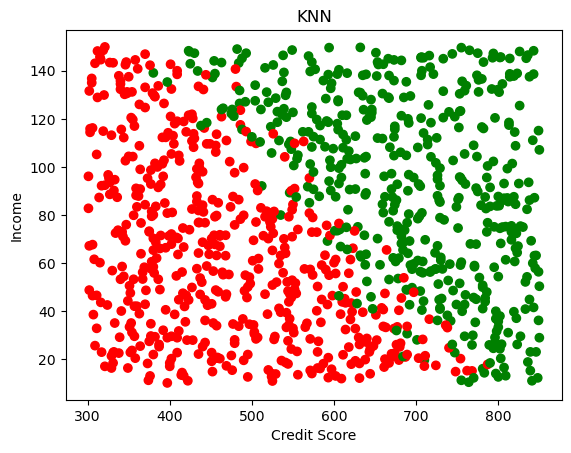

In [13]:
colors = df['Loan Eligible'].map({'Yes': 'green', 'No': 'red'})
plt.scatter(df['Credit Score'],df['Income'],c=colors)
plt.xlabel("Credit Score")
plt.ylabel('Income')
plt.title('KNN')

In [14]:
df.head(1)

,Credit Score,Income,Loan Eligible
0,414,13.5,No


In [19]:
X = df.drop(['Loan Eligible'],axis =1)
y = df['Loan Eligible'].map({"Yes": 1,"No":0})

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
Scaler = StandardScaler()
X_train_scale = Scaler.fit_transform(X_train)
X_test_scale = Scaler.transform(X_test)

In [53]:
K =  5
model = KNeighborsClassifier(n_neighbors=K)
model.fit(X_train_scale,y_train)

KNeighborsClassifier()

In [54]:
y_pred = model.predict(X_test_scale)

In [57]:
accuracy = accuracy_score(y_test, y_pred)
misclassification_rate = 1 - accuracy

In [59]:
print(f"\nK = {K}")
print(f"Accuracy: {accuracy:.2%}")
print(f"Misclassification Rate: {misclassification_rate:.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


K = 5
Accuracy: 95.00%
Misclassification Rate: 5.00%

Confusion Matrix:
[[101   5]
 [  5  89]]


In [64]:
new_point = pd.DataFrame([[710, 65]], columns=["Credit Score", "Income"])
prediction = model.predict(new_point)
result = "Yes" if prediction[0] == 1 else "No"
print("Loan Eligible:", result)

Loan Eligible: Yes
